就是把 val 里的 x 放进你已经在 train 上拟合好的模型里，得到预测值 \hat y，再拿它和 val 里真正的 y 比较误差。 这正是 brief 写的流程：训练集用来拟合参数，验证集用来做 model selection、评估性能和分析泛化，而且不能用于训练。   

In [7]:
%pip install numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


=== Step 1: Dataset overview ===
Training set shape: (400, 2)
Validation set shape: (100, 2)

Training set head:
          x          y
0  1.095824   1.635425
1 -0.244486  -0.338836
2  1.434392   3.926012
3  0.789472  -0.027757
4 -1.623291  11.301925

Validation set head:
          x          y
0 -0.792290   0.380422
1  1.673768   6.860788
2  1.125176   1.614931
3 -1.557646   9.929234
4  1.988139  14.135489

Training summary statistics:
                x           y
count  400.000000  400.000000
mean    -0.013815    3.786131
std      1.140097    5.321142
min     -1.970551   -0.880020
25%     -1.040343    0.006840
50%     -0.034280    1.264769
75%      1.032783    6.678148
max      1.969502   23.986848

Validation summary statistics:
                x           y
count  100.000000  100.000000
mean    -0.031115    4.368830
std      1.180395    6.003807
min     -1.978281   -0.609834
25%     -1.145332    0.180854
50%      0.123767    1.466492
75%      0.864335    6.899558
max      1.996419

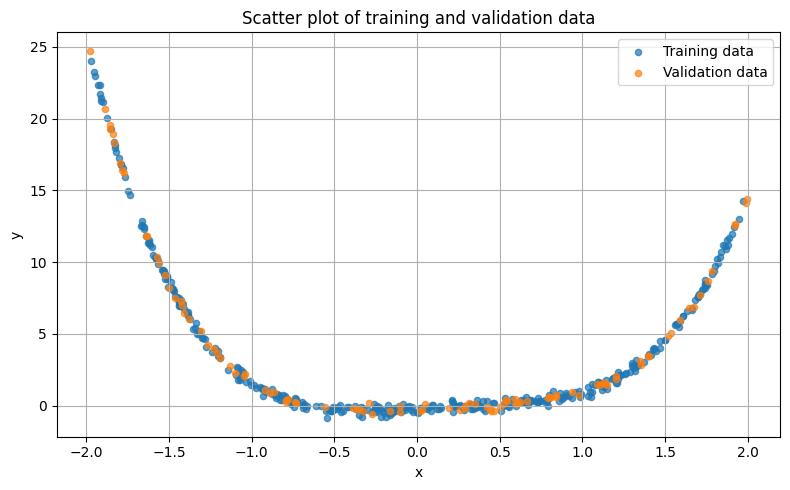

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv('train.csv')  #loads train dataset
val_df = pd.read_csv('val.csv') #loads validation dataset

#.to_numpy(dtype=float): converts the table into NumPy arrays for matrix operations.
#Why use [['x']] instead of ['x']
#Because:['x'] gives a 1D Series;[['x']] gives a 2D DataFrame
#Neural network code and matrix multiplication are easier and safer with shape (n,1).

x_train = train_df[['x']].to_numpy(dtype=float) #extracts the input variable x while keeping a 2D shape.
y_train = train_df[['y']].to_numpy(dtype=float) #extracts the target y
x_val = val_df[['x']].to_numpy(dtype=float)
y_val = val_df[['y']].to_numpy(dtype=float)

print('=== Step 1: Dataset overview ===')
print('Training set shape:', train_df.shape)
print('Validation set shape:', val_df.shape)
print('\nTraining set head:')
print(train_df.head())
print('\nValidation set head:')
print(val_df.head())
print('\nTraining summary statistics:')
print(train_df.describe())
print('\nValidation summary statistics:')
print(val_df.describe())

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s=20, alpha=0.7, label='Training data')
plt.scatter(x_val, y_val, s=20, alpha=0.7, label='Validation data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of training and validation data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

•	The scatter plot shows a clear nonlinear relationship between x and y, so a simple linear model would be inappropriate.  
•	Both the training and validation points follow a very similar smooth U-shaped trend, suggesting they come from the same underlying distribution.  
•	The points are close to the main curve but not exactly on it, which indicates the data contains noise while still preserving a strong overall pattern.  
•	The shape appears smooth and moderately asymmetric, which suggests that a fourth-order polynomial is a reasonable baseline for approximating the function.  
•	Since the validation data overlaps well with the training data, the validation set should provide a fair way to assess generalisation performance and compare the polynomial model with the neural network.

## Step 2: Prepare training and validation data

在这一部分，我们只对神经网络模型使用标准化（standardisation），而不对前面的 least squares / polynomial regression 做标准化处理。
标准化的目标，是把数据转换到一个更适合神经网络训练的尺度上。
具体来说，就是把输入变量 x 和目标变量 y 都调整为：
	•	均值接近 0
	•	标准差接近 1

这样做可以让神经网络在训练时更稳定，也更容易收敛。

这里采用的方法是：
	1.	先只用训练集（training set）计算均值和标准差
	2.	再用这些训练集得到的参数，去标准化训练集和验证集
	3.	神经网络在标准化后的数据上训练和验证



In [ ]:
x_mean = x_train.mean(axis=0) # computes the mean of training inputs.
x_std = x_train.std(axis=0) #computes the standard deviation of training inputs.
y_mean = y_train.mean(axis=0) #computes the mean of training targets.
y_std = y_train.std(axis=0) #computes the standard deviation of training targets.

x_train_scaled = (x_train - x_mean) / x_std #standardises training inputs.
x_val_scaled = (x_val - x_mean) / x_std #standardises validation inputs using training statistics.
y_train_scaled = (y_train - y_mean) / y_std #standardises training targets.
y_val_scaled = (y_val - y_mean) / y_std #tandardises validation targets similarly. 